In [171]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# append my path
project_root = os.path.abspath('..')
sys.path.append(project_root)

from utils.utils import *

In [172]:
data = load_saved_data("data_with_spikes_and_speed")

In [173]:
def fit_tuning_curves(
    data,
    session="B",
    stimulus="drifting_gratings",
    parameter="orientation",
    speed_phase=None,
):
    """Compute per-trial spike counts and fit a von Mises tuning curve per cell,
    in one pass over the stimulus table. 
    Also allows filtering trials based on running speed phase (e.g., still vs running).
    """
    session_data = data["sessions"][session]
    spikes = np.asarray(session_data["spikes"], dtype=float)
    stim_table = session_data["stim_tables"][stimulus]
    running_speed_phase = session_data["running_speed_phase"]

    n_cells = spikes.shape[0]
    # Hold spike counts and stimulus values for each cell
    counts_per_cell = [[] for _ in range(n_cells)]
    stim_per_cell = [[] for _ in range(n_cells)]

    for _, trial in stim_table.iterrows():
        start_idx = int(trial["start"])
        stop_idx = int(trial["end"])
        stim_value = trial[parameter]
        
        if speed_phase is not None:
            samples_in_phase = running_speed_phase[start_idx:stop_idx] == speed_phase
            if not np.any(samples_in_phase):
                continue
            # Count spikes only in the samples that match the specified speed phase
            spike_count = np.sum(spikes[:, start_idx:stop_idx][:, samples_in_phase], axis=1)
        else:
            spike_count = np.sum(spikes[:, start_idx:stop_idx], axis=1)
        
        # Store spike counts and stimulus values for each cell
        for cell_idx in range(n_cells):
            counts_per_cell[cell_idx].append(spike_count[cell_idx])
            stim_per_cell[cell_idx].append(stim_value)
            
    # Fit tuning curves for each cell
    fitted_params = []
    for cell_idx in range(n_cells):
        counts = np.asarray(counts_per_cell[cell_idx], dtype=float) # shape (n_trials,)
        stim = np.asarray(stim_per_cell[cell_idx], dtype=float) # shape (n_trials,)
        
        # Remove NaN or infinite values 
        valid = np.isfinite(counts) & np.isfinite(stim)
        counts = counts[valid]
        stim = stim[valid]

        params = tuningCurve(counts, stim)
        fitted_params.append(
            {
                "cell": cell_idx,
                "stimulus_parameters": stim,
                "spike_counts": counts,
                "van-mises-params": params,
                "speed_phase": speed_phase
            }
        )

    return fitted_params

In [174]:
def compute_tuning_significance(fitted_params, psi=2, niters=1000, random_seed=2046):
    """Permutation-based tuning significance per cell.
    """
    p_values = {}
    for entry in fitted_params:
        cell = int(entry["cell"])
        stim = np.asarray(entry["stimulus_parameters"], dtype=float)
        counts = np.asarray(entry["spike_counts"], dtype=float)

        p_value, q_abs, _ = testTuning(
            counts, stim, psi=psi, niters=niters, random_seed=random_seed
        )
        p_values[cell] = p_value

    return p_values

In [175]:
def plot_tuning_curves(
    fitted_params,
    p_values=None,
    n_cols=4,
    alpha=0.05,
    psi=2,
):
    """Plot per-cell trial rates and von Mises fit."""
    
    n_cells = len(fitted_params)
    n_rows = int(np.ceil(n_cells / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows), squeeze=False)
    # Define the range of theta values for plotting
    theta_range = np.linspace(0, np.max([entry["stimulus_parameters"] for entry in fitted_params]), 200) 
    speed_phase = fitted_params[0]['speed_phase'] if fitted_params else 0
    
    for i, entry in enumerate(fitted_params):
        row, col = divmod(i, n_cols)
        ax = axes[row, col]

        cell = int(entry["cell"])
        stim = np.asarray(entry["stimulus_parameters"], dtype=float) # shape (n_trials,) the orientations
        counts = np.asarray(entry["spike_counts"], dtype=float) # shape (n_trials,)
        # compute mean spike counts for each unique stimulus value
        unique_stim = np.unique(stim)
        mean_counts = np.array([np.mean(counts[stim == us]) for us in unique_stim])
        alpha_vm, kappa_vm, nu_vm, phi_vm = entry["van-mises-params"]

        ax.scatter(unique_stim, mean_counts, color="black", s=10, label="Mean spike count")
        fitted_curve = vonMises(theta_range, alpha_vm, kappa_vm, nu_vm, phi_vm)
        ax.plot(theta_range, fitted_curve, color="crimson" if speed_phase == 0 else "blue", label="von Mises fit")

        # Significance styling: green title/border if tuned, plain otherwise.
        is_sig = p_values is not None and p_values.get(cell, 1) < alpha
        title = f"Cell {cell}" + (f" *, p: {p_values[cell]:.3f}" if is_sig else "")
        ax.set_title(title, fontsize=10, color="green" if is_sig else "black")
        if is_sig:
            for spine in ax.spines.values():
                spine.set_edgecolor("green")
                spine.set_linewidth(2)
        if i == 0:
            ax.set_xlabel("Orientation (deg)")
            ax.set_ylabel("Spike count")
            ax.legend(fontsize=7)
            
        ax.set_ylim(bottom=0, top=max(fitted_curve) * 1.5)

    for j in range(n_cells, n_rows * n_cols):
        row, col = divmod(j, n_cols)
        axes[row, col].axis("off")

    speed_phase_str = "still" if speed_phase == 0 else "running"
    psi_str = "Direction selectivity" if psi == 1 else "Orientation selectivity"
    fig.suptitle(f"{psi_str}, movement phase: {speed_phase_str}", fontsize=13, y=1.0)
    fig.tight_layout()
    return fig, axes

## 1. Drifting gratings

### 1.1 Direction selectivity, no movement

In [176]:
PSI = 1

In [177]:
fitted_params = fit_tuning_curves(
    data,
    session="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    speed_phase=0 # still
)

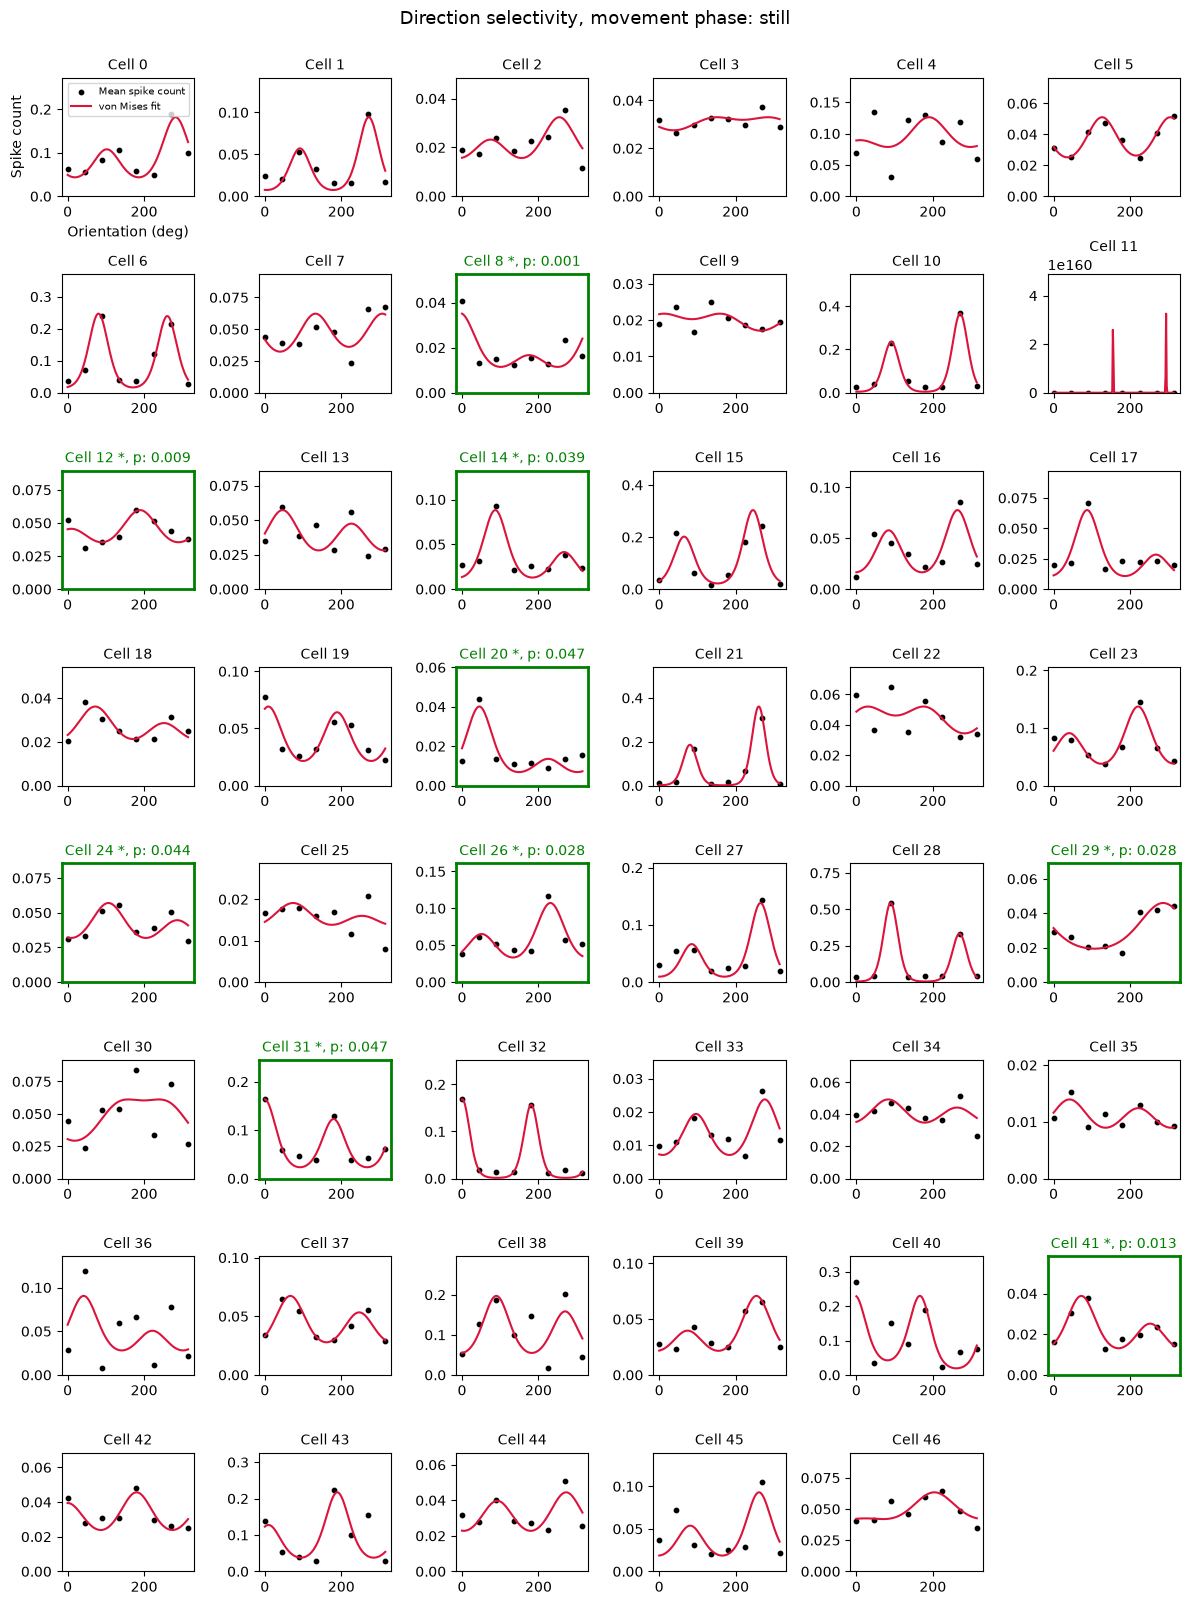

In [178]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=6,
    alpha=0.05,
    psi=PSI
)
plt.show()

### 1.1 Movement

In [179]:
fitted_params = fit_tuning_curves(
    data,
    session="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    speed_phase=1 # running
)

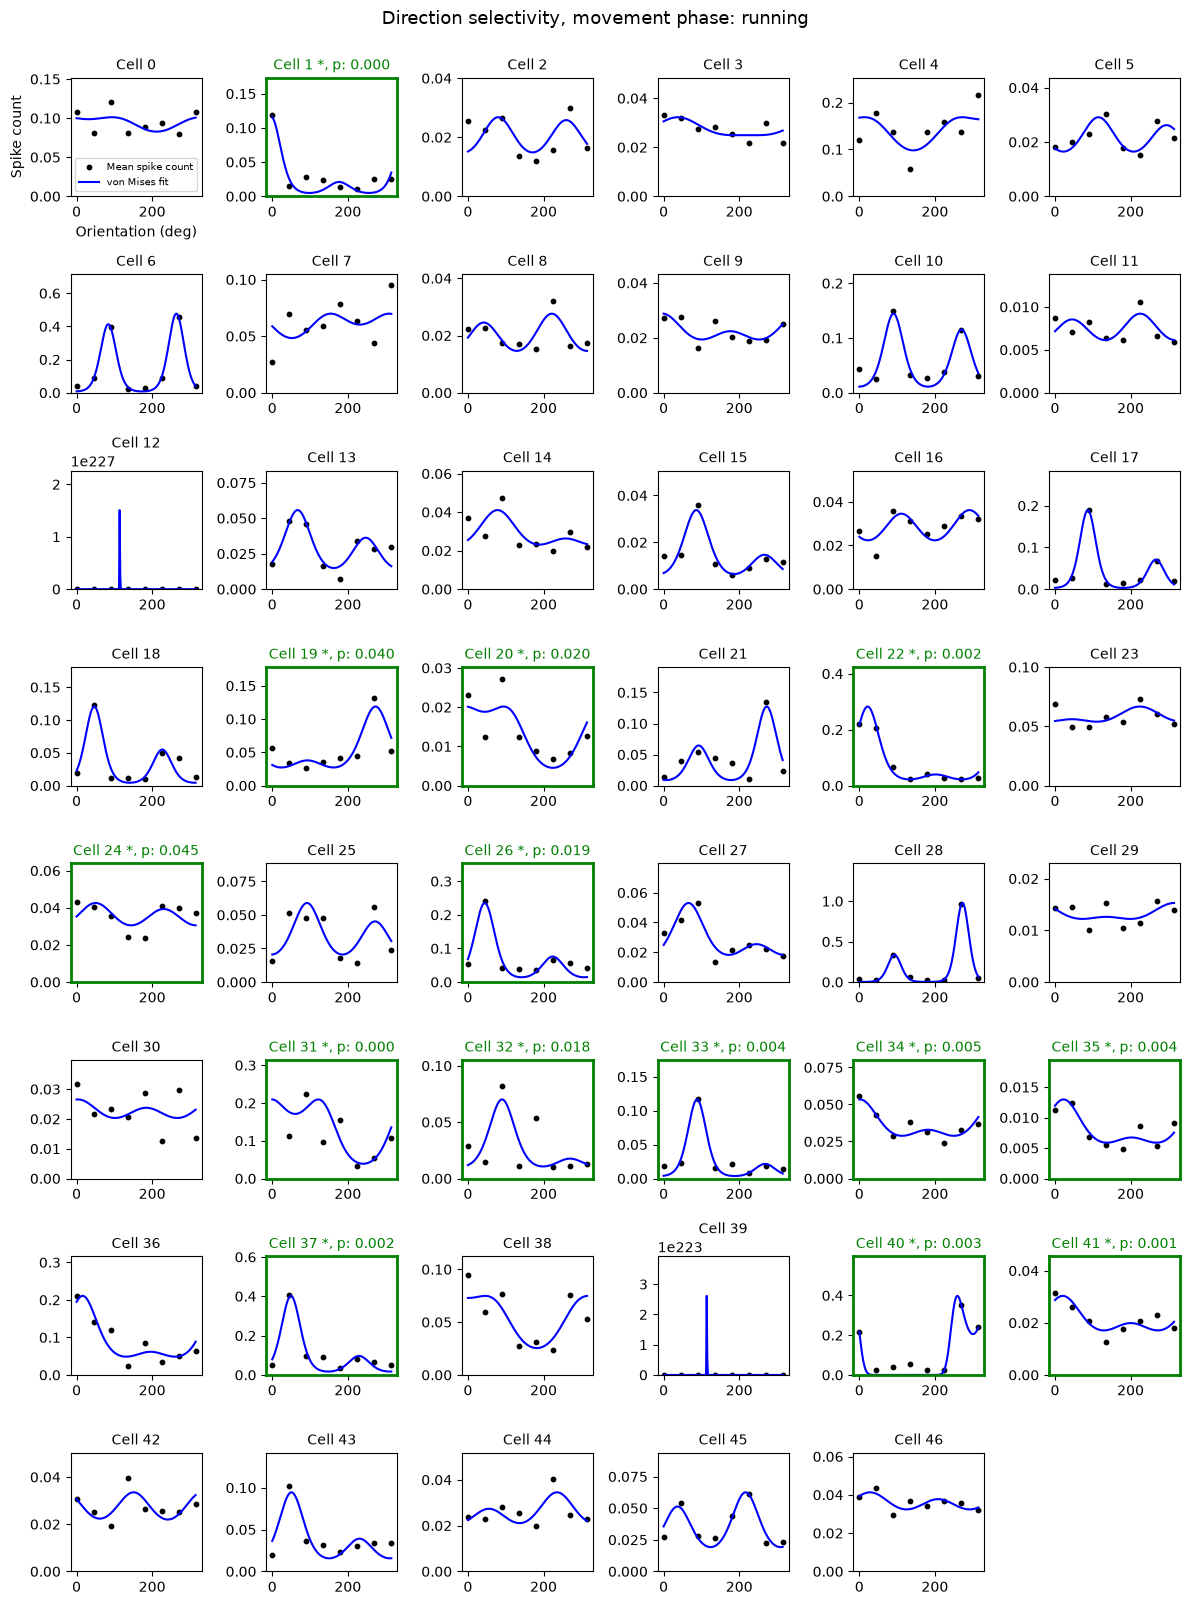

In [180]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=6,
    alpha=0.05,
    psi=PSI
)
plt.show()

## 2. Static gratings

2.1 Without movement

In [181]:
PSI = 2

In [182]:
fitted_params = fit_tuning_curves(
    data,
    session="B",
    stimulus="static_gratings",
    parameter="orientation",
    speed_phase=0 # still
)

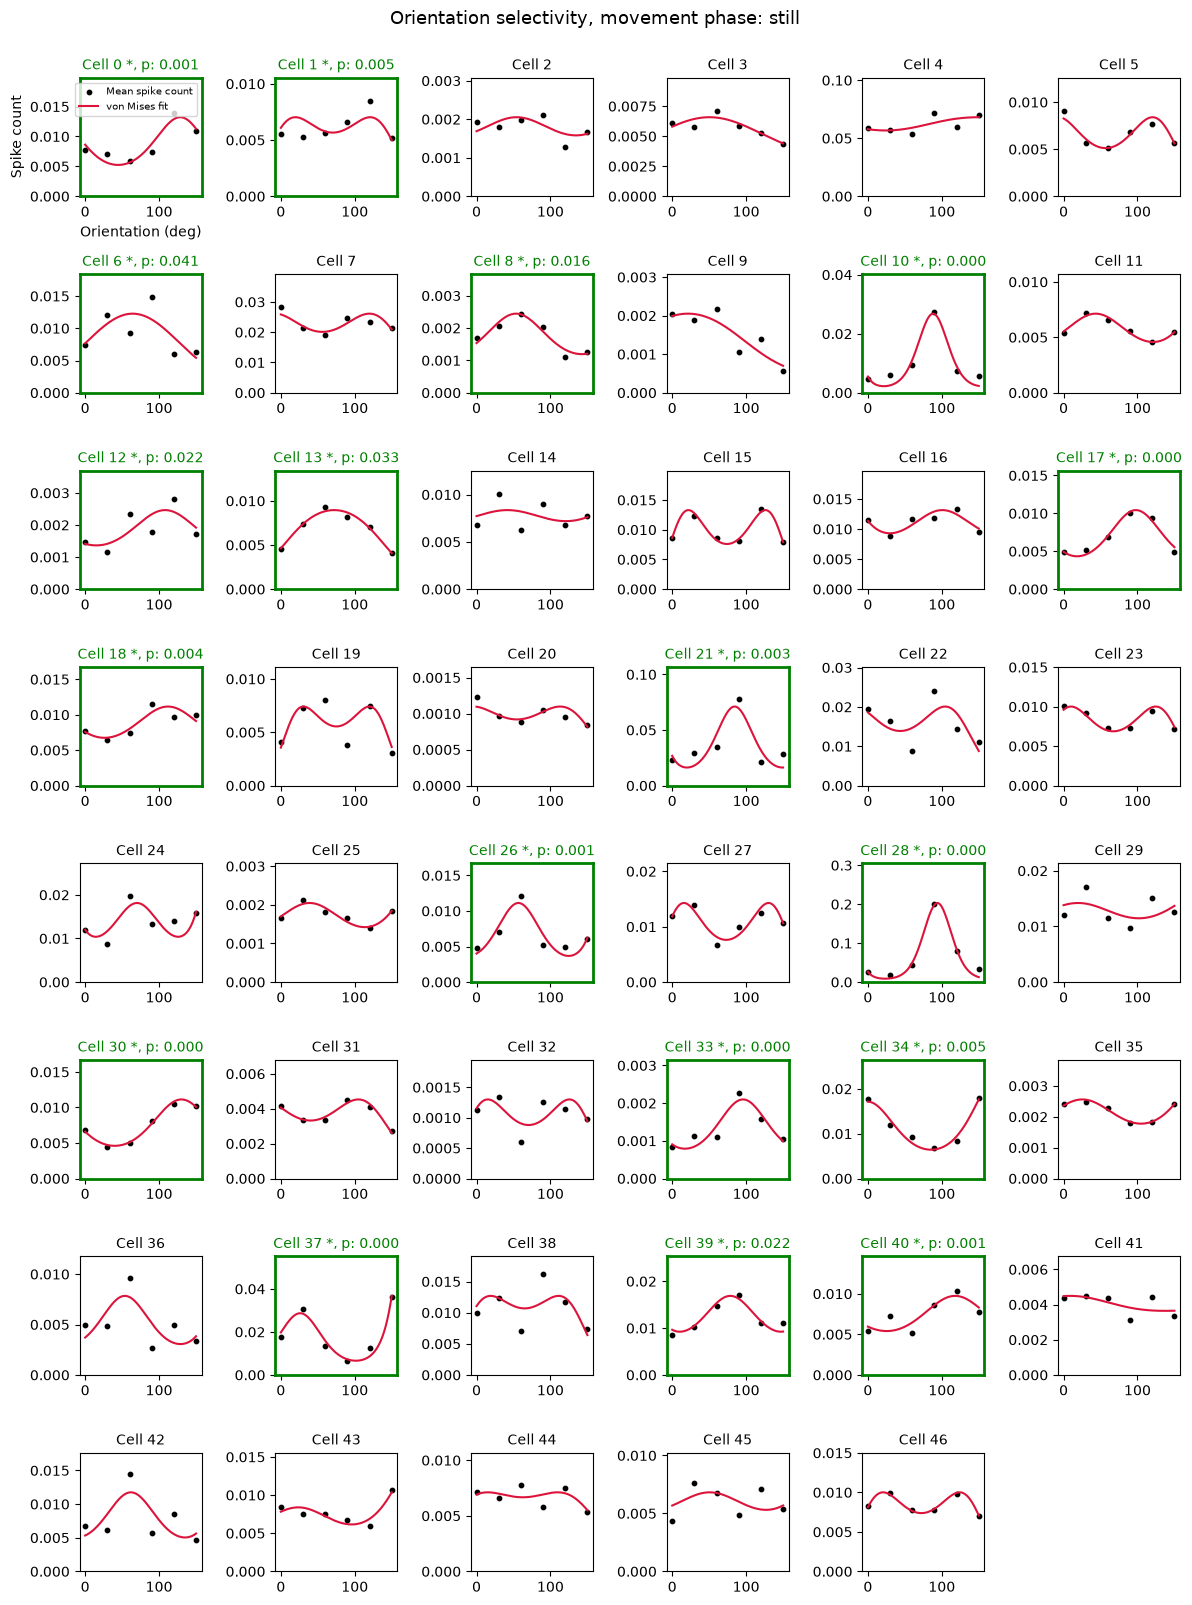

In [183]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=6,
    alpha=0.05,
    psi=PSI
)
plt.show()

### 2.2 With movement

In [184]:
fitted_params = fit_tuning_curves(
    data,
    session="B",
    stimulus="static_gratings",
    parameter="orientation",
    speed_phase=1 # running
)

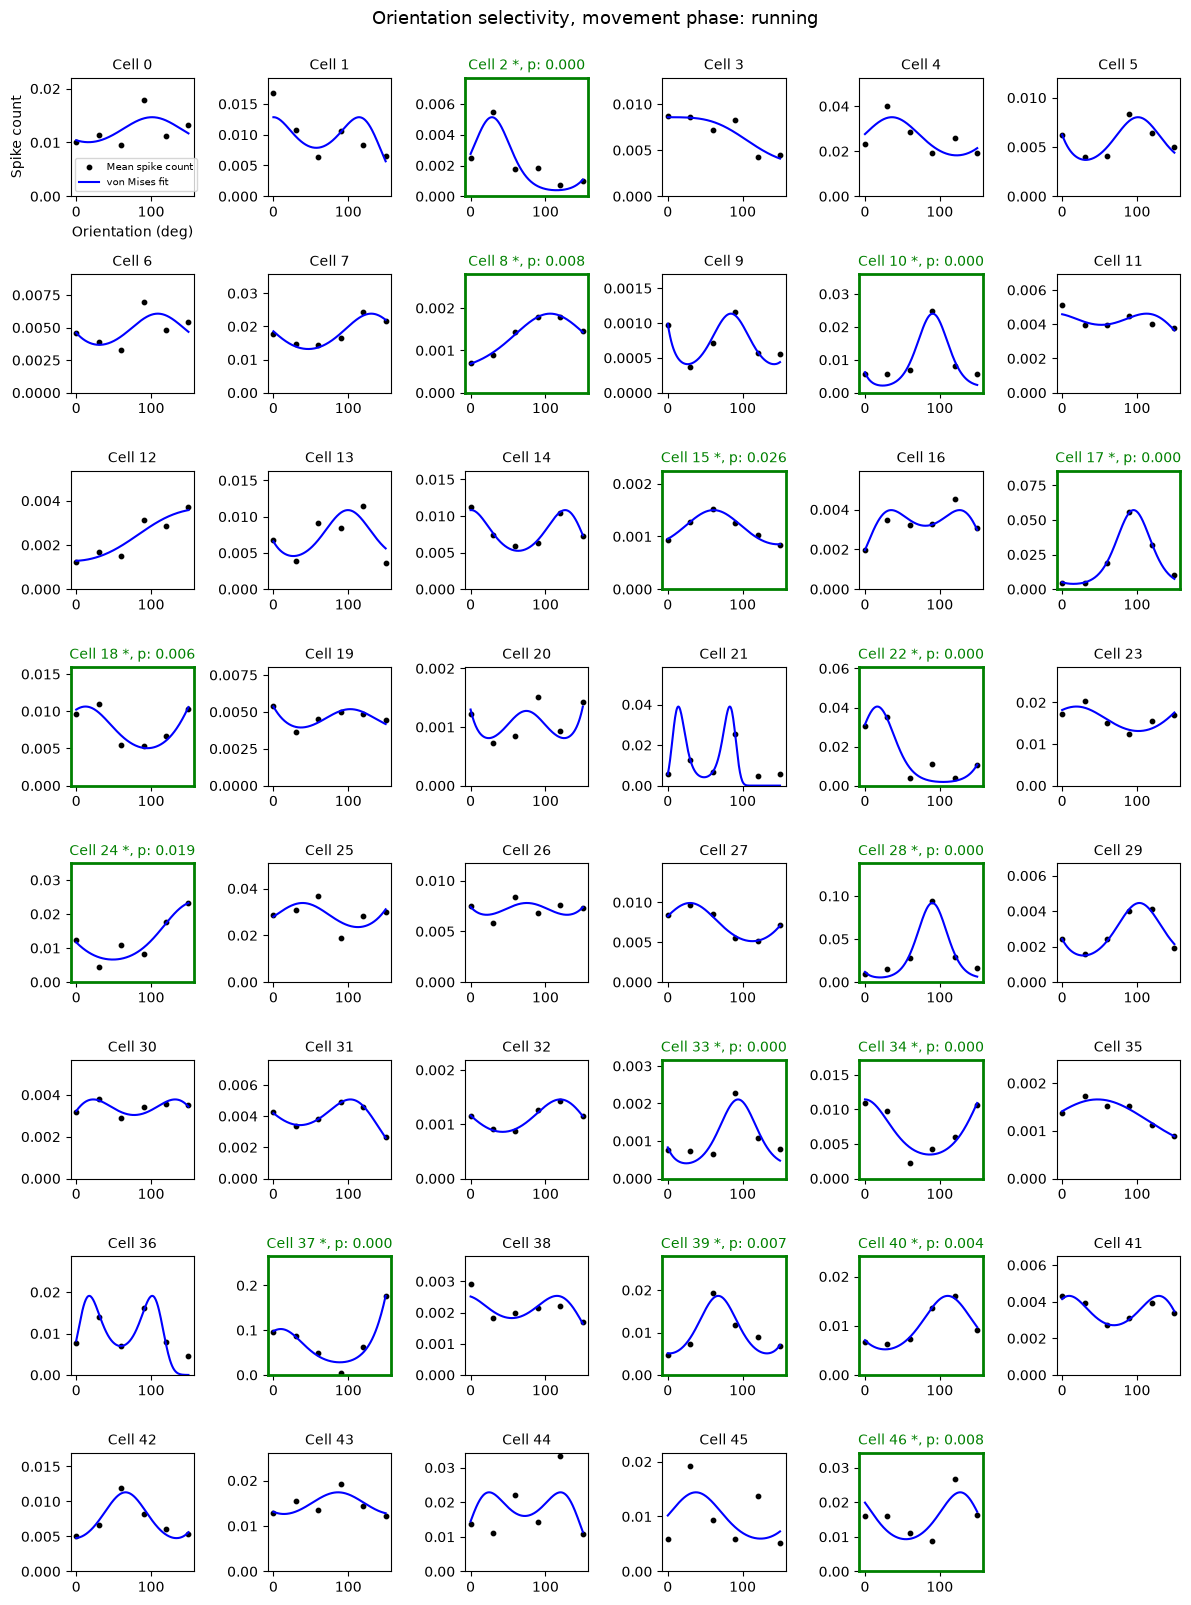

In [185]:
p_values = compute_tuning_significance(
    fitted_params,
    psi=PSI, # test orientation selectivity (Fourier mode)
    niters=1000,
    random_seed=2046
)

fig, axes = plot_tuning_curves(
    fitted_params,
    p_values=p_values,
    n_cols=6,
    alpha=0.05,
    psi=PSI
)
plt.show()